# Example Problem for Machine Learning 02 - Linear Regression

This is one of the most basic machine learning problems:  
Given input and output, try to find the coefficients of a quadratic curve ($ y = ax^2 + bx + c $) via linear regression.

REF: This article contains some content from [TensorFlow basics](https://www.tensorflow.org/guide/basics).

## 1. Setup

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

2026-04-19 14:11:36.610923: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-19 14:11:36.629157: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776579096.643763    3243 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776579096.648959    3243 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776579096.661635    3243 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 2. Data preperation

Create a [`quadratic curve`](https://en.wikipedia.org/wiki/Quadratic_function) 
$$ y = ax^2 + bx + c , $$
where $a \neq 0$. In this example, we need the curve opens upwards, i.e., $a > 0$.

Factor names:
|   |                $a$  |               $b$  |                $c$  |
| - | ------------------- | ------------------ | ------------------- |
| 1 | Second order factor | First order factor | Zeroth order factor |
| 2 | Quadratic weight    | Linear weight      | Bias or offset      |

The scattered data points are made by `quadratic curve` + `Gaussian noise`.




In [2]:
# Create an actual curve: f_TRUE(x) = factor_a * x**2 + factor_b * x + factor_c

# Set curve factors
factor_a =  1.0      # Second order factor / quadratic_weight
factor_b =  2.0      # First order factor  / Linear_weight
factor_c = -5.0      # Zeroth order factor / bias / offset 
Num_Samples = 201   # Number of sample points, i.e., $N_{dataset}$

x = tf.linspace(-2.0, 2.0, 201)     # A vector of x values within a specific range

x = tf.cast(x, tf.float32)          # Convert a tensor from `tf.float64` to `tf.float32`
                                    # In this example, we don't need very high precision. 
                                    # Meanwhile, we can save computational resources.

# Define the function of actual curve
def f_TRUE(x):
    y = factor_a * x**2 + factor_b * x + factor_c
    return y

# Generate Gaussian noise (random values from a normal distribution).
sigma_value = 1.0  # Set the standard deviation (sigma value) of the normal distribution
Gaussian_noise = tf.random.normal(shape=[Num_Samples], stddev=sigma_value)  # Default setting: stddev=1.0

# Calculate the data y_data = the actual curve + Gaussian noise
y_data = f_TRUE(x) + Gaussian_noise

I0000 00:00:1776579123.130610    3243 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


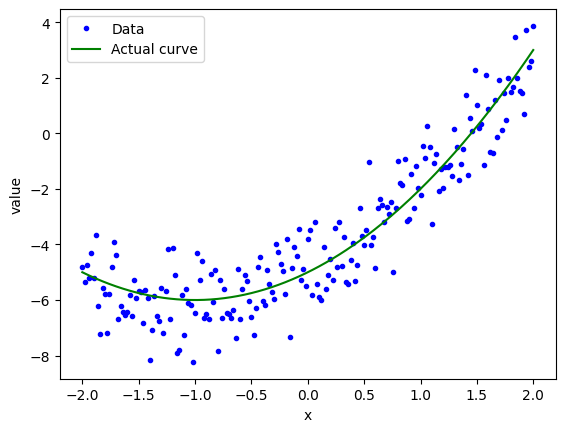

In [3]:
# Plot all the data and the actual line
plt.plot(x,    y_data, '.', color="b", label="Data")
plt.plot(x, f_TRUE(x),      color="g", label="Actual curve")
plt.legend();
plt.xlabel("x")
plt.ylabel("value")
plt.show()

## 3. Model establishing

Create a `quadratic model` with randomly initialized weights and a bias:

In [4]:
class MyModel(tf.Module):
    def __init__(self):
        # Randomly generate weight and bias terms
        rand_init = tf.random.uniform(shape=[3], minval=0, maxval=5, seed=22)  # This is an EagerTensor object. 
        # Initialize model parameters
        self.w_q = tf.Variable(rand_init[0], name="w_q")    # quadratic weight
        self.w_l = tf.Variable(rand_init[1], name="w_l")    # linear weight
        self.b   = tf.Variable(rand_init[2], name="b")      # bias

    # Using the `tf.function` decorator makes the defined function into a `PolymorphicFunction`.
    # Graph execution
    @tf.function
    def __call__(self, x):
        # Quadratic Model: quadratic_weight * x^2 + linear_weight * x + bias
        return self.w_q * (x**2) + self.w_l * x + self.b

First, observe our model's performance before training:

In [5]:
quad_model = MyModel()

# Check variables
quad_model.variables

(<tf.Variable 'b:0' shape=() dtype=float32, numpy=4.689265251159668>,
 <tf.Variable 'w_l:0' shape=() dtype=float32, numpy=4.387016296386719>,
 <tf.Variable 'w_q:0' shape=() dtype=float32, numpy=1.4291572570800781>)

In [6]:
# Check trainable variables
quad_model.trainable_variables

(<tf.Variable 'b:0' shape=() dtype=float32, numpy=4.689265251159668>,
 <tf.Variable 'w_l:0' shape=() dtype=float32, numpy=4.387016296386719>,
 <tf.Variable 'w_q:0' shape=() dtype=float32, numpy=1.4291572570800781>)

In [7]:
def plot_preds(x, y, f, model, title):
    plt.figure()
    plt.plot(x,        y, '.', color="b", label='Data')
    plt.plot(x,     f(x),      color="g", label='Actual curve')
    plt.plot(x, model(x),      color="r", label='Predictions')
    plt.title(title)
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("value")

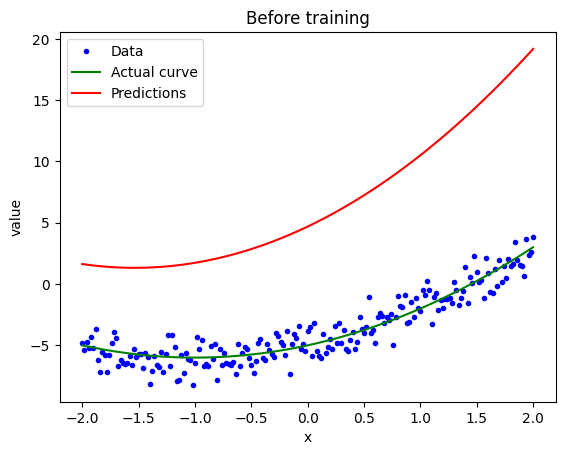

In [8]:
plot_preds(x, y_data, f_TRUE, quad_model, "Before training")

It's obvious that the predicted curve before training (red curve) is far from the data points (blue dots).

## 4. Loss function

Now, define a loss for our model:

Given that this model is intended to predict continuous values, the `mean squared error (MSE)` is a good choice for the loss function. Given a vector of predictions, $\hat{y}$, and a vector of true targets, $y$, the MSE is defined as the mean of the squared differences between the predicted values and the actual curve.

$$ MSE = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i -y_i)^2 $$

In [9]:
def loss_MSE(y_pred, y):
    return tf.reduce_mean(tf.square(y_pred - y))

## 5. Batching and shuffling

Write a basic training loop for the model. The loop will make use of the MSE loss function and its gradients with respect to the input in order to iteratively update the model's parameters. 

Using `mini-batches` for training provides both memory efficiency and faster convergence. The [`tf.data.Dataset`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset) API has useful functions for `batching` and `shuffling`.

In [10]:
# Set parameters
shuffle_size = x.shape[0]
batch_size   = 32

# Creates a `Dataset` whose elements are slices of the given tensors.
dataset = tf.data.Dataset.from_tensor_slices((x, y_data))

# list(dataset.as_numpy_iterator())     # Use `as_numpy_iterator` to inspect the content of your dataset. 
                                        # To see element shapes and types, print dataset elements directly.

# Shuffle and batch the dataset
dataset = dataset.shuffle(buffer_size=shuffle_size).batch(batch_size)

## 6. Training loop

In [11]:
# Set training parameters
num_epochs    = 100
learning_rate = 0.01
losses        = []

# Format training loop
for epoch in range(num_epochs):
    for x_batch, y_batch in dataset:
        with tf.GradientTape() as tape:
            batch_loss = loss_MSE(quad_model(x_batch), y_batch)

        # Update parameters with respect to the gradient calculations
        dloss_dvar = tape.gradient(batch_loss, quad_model.variables)
        # Parallel iteration
        for var, dl_dvar in zip(quad_model.variables, dloss_dvar):
            var.assign_sub(learning_rate * dl_dvar)

    # Keep track of model loss per epoch
    loss = loss_MSE(quad_model(x), y_data)
    losses.append(loss)

    # Display progress every 10 epochs
    if epoch % 10 == 0:
        print(f"Mean square error (MSE) for step {epoch}: {loss.numpy():0.3f}")

2026-04-19 14:12:07.780451: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-19 14:12:07.815816: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-19 14:12:07.878564: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Mean square error (MSE) for step 0: 56.478


2026-04-19 14:12:07.997814: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Mean square error (MSE) for step 10: 9.439


2026-04-19 14:12:08.223541: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Mean square error (MSE) for step 20: 3.885
Mean square error (MSE) for step 30: 1.976


2026-04-19 14:12:08.690518: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Mean square error (MSE) for step 40: 1.306
Mean square error (MSE) for step 50: 1.075
Mean square error (MSE) for step 60: 0.998


2026-04-19 14:12:09.535630: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Mean square error (MSE) for step 70: 0.968
Mean square error (MSE) for step 80: 0.957
Mean square error (MSE) for step 90: 0.953


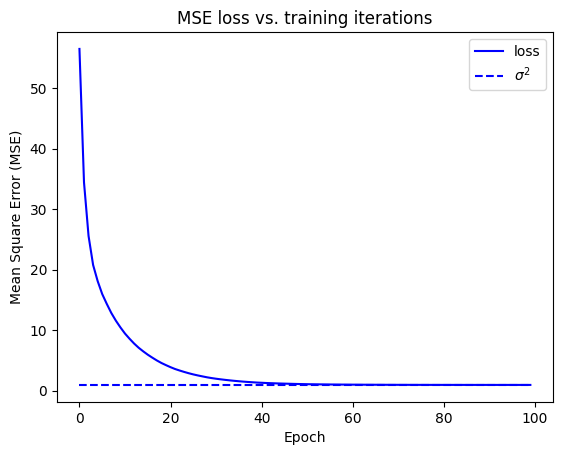

In [12]:
# Plot training results
plt.plot(range(num_epochs), losses, color="b", label="loss")
plt.plot(range(num_epochs), [sigma_value**2] * len(range(num_epochs)), "--",
         color="b", label="$\\sigma^2$")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Mean Square Error (MSE)")
plt.title('MSE loss vs. training iterations');

As the epoch increases, the loss is close to 1.

## 7. Result evaluation

Now, observe our model's performance after training:

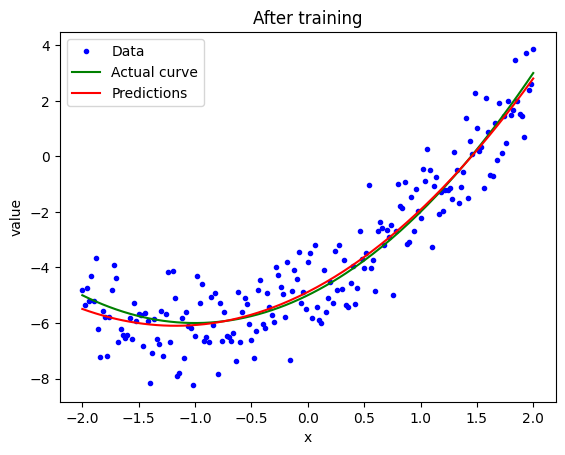

In [13]:
# Visualize how the trained curve performs:
plot_preds(x, y_data, f_TRUE, quad_model, "After training")

The predicted curve after training (red curve) is close to the data points (blue dots) and the actual curve (green curve).